# Predictive Coding with convolutions

Minimal notebook setup for exploring predictive coding with NumPy, PyTorch, and torchvision.

In [187]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import math

In [188]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")

Using device: cpu
PyTorch: 2.13.0
NumPy: 2.5.2


dataset/input variables

In [189]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

input_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

Training Loop

In [190]:
def train_loop(I, U, r, f, f_prime, alpha, lambda_u, lr_r, lr_U, sigma_2, num_epochs_outer, num_epochs_inner, num_layers):
    I = I.reshape(-1, 1).float()
    e = [None] * num_layers

    for out_epoch in range(num_epochs_outer):
        for in_epoch in range(num_epochs_inner):
            e[0] = I - f(U[0] @ r[0])
            
            for i in range(1, num_layers):
                e[i] = r[i - 1] - f(U[i] @ r[i])

            for i in range(num_layers):
                cauchy_prior = alpha * (2 * r[i] / (1 + r[i] ** 2))
                dr = (1.0 / sigma_2) * U[i].T @ (f_prime(U[i] @ r[i]) * e[i]) - cauchy_prior
                if i < num_layers - 1:
                    dr = dr - (1.0 / sigma_2) * e[i + 1]
                r[i] = r[i] + lr_r * dr

        e[0] = I - f(U[0] @ r[0])
        
        for j in range(1, num_layers):
            e[j] = r[j - 1] - f(U[j] @ r[j])
        
        for j in range(num_layers):
            du = (1.0 / sigma_2) * (f_prime(U[j] @ r[j]) * e[j]) @ r[j].T - lambda_u * U[j]
            U[j] = U[j] + lr_U * du
            U[j] = U[j] / (torch.norm(U[j], dim=0, keepdim=True) + 1e-8)

    return U, r


validation


In [191]:
def validate_heirarchical(I, U, r, num_layers, f):
    I = I.reshape(-1, 1).float()
    
    I_hat_L0 = f(U[0] @ r[0])
    
    h = r[num_layers - 1]
    for i in range(num_layers - 1, -1, -1):
        h = f(U[i] @ h)
    I_hat_top_down = h
    
    mse_L0 = torch.mean((I - I_hat_L0) ** 2)
    mse_top_down = torch.mean((I - I_hat_top_down) ** 2)
    
    return mse_L0, mse_top_down, I_hat_L0, I_hat_top_down


In [192]:
def to_I(image):
    I = image.float().reshape(-1, 1)
    return I, I.numel()


In [ ]:
def make_variables(image, initial_r_size=512, k1_per_patch=32, num_layers=4, num_patches=16):
    I, size = to_I(image)
    k_step_size = (initial_r_size - k1_per_patch) // (num_layers - 1)
    k = [k1_per_patch * num_patches]
    for _ in range(num_layers - 1):
        k.append(k[-1] - k_step_size)
    r = [torch.randn(k[i], 1) * 0.1 for i in range(num_layers)]
    return I, k, r, size

def random_patch_col(images, size, num_patches=16, H=28):
    grid = int(math.sqrt(num_patches))
    ps = H // grid
    img = images[torch.randint(len(images), (1,)).item()].float().reshape(H, H)
    p = torch.randint(0, num_patches, (1,)).item()
    i, j = divmod(p, grid)
    canvas = torch.zeros(H, H)
    tile = img[i * ps:(i + 1) * ps, j * ps:(j + 1) * ps]
    canvas[i * ps:(i + 1) * ps, j * ps:(j + 1) * ps] = tile
    col = canvas.reshape(-1)
    return col / (col.norm() + 1e-8)

def init_U(images, size, k, num_layers, num_patches=16, H=28):
    grid = int(math.sqrt(num_patches))
    ps = H // grid
    k1 = k[0] // num_patches
    cols = []
    for p in range(num_patches):
        i, j = divmod(p, grid)
        for _ in range(k1):
            img = images[torch.randint(len(images), (1,)).item()].float().reshape(H, H)
            canvas = torch.zeros(H, H)
            tile = img[i * ps:(i + 1) * ps, j * ps:(j + 1) * ps]
            canvas[i * ps:(i + 1) * ps, j * ps:(j + 1) * ps] = tile
            cols.append(canvas.reshape(-1) / (canvas.norm() + 1e-8))
    U = [torch.stack(cols, dim=1)]
    for i in range(num_layers - 1):
        Ui = torch.randn(k[i], k[i + 1]) * 0.1
        U.append(Ui / (torch.norm(Ui, dim=0, keepdim=True) + 1e-8))
    return U

def refresh_U(U, images, r0_list, size, num_patches=16, dead_thresh=0.05, clone_thresh=0.95):
    R = torch.cat(r0_list, dim=1)
    dead = R.abs().mean(dim=1) < dead_thresh
    cols = U[0] / (U[0].norm(dim=0, keepdim=True) + 1e-8)
    sim = cols.T @ cols
    sim.fill_diagonal_(0)
    cloned = sim.abs().max(dim=0).values > clone_thresh
    for j in (dead | cloned).nonzero().flatten():
        U[0][:, j] = random_patch_col(images, size, num_patches)
    U[0] = U[0] / (torch.norm(U[0], dim=0, keepdim=True) + 1e-8)
    return U



test it

In [194]:
def test(I, U, r, f, f_prime, num_epochs_inner, num_layers, sigma_2, alpha, lr_r):
    I = I.reshape(-1, 1).float()
    e = [None] * num_layers
    for in_epoch in range(num_epochs_inner):
        e[0] = I - f(U[0] @ r[0])
        for i in range(1, num_layers):
            e[i] = r[i - 1] - f(U[i] @ r[i])
        for i in range(num_layers):
            prior = alpha * (2 * r[i] / (1 + r[i] ** 2))
            dr = (1.0 / sigma_2) * U[i].T @ (f_prime(U[i] @ r[i]) * e[i]) - prior
            if i < num_layers - 1:
                dr = dr - (1.0 / sigma_2) * e[i + 1]
            r[i] = r[i] + lr_r * dr
    return U, r


Starting Training: 100 Epochs | 100 Images | 2 Layers
Hyperparameters: lr_r=0.005, lr_U=0.002, alpha=0.001, lambda_u=0.001
[Epoch 000/100]  Layer 0 MSE: nan (|r0|: nan)  |  Layer 1 MSE: nan (|r1|: nan)


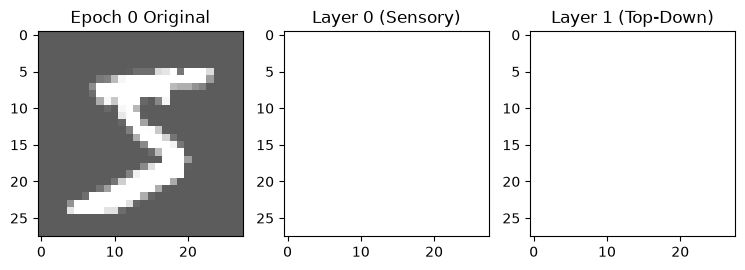

[Epoch 005/100]  Layer 0 MSE: nan (|r0|: nan)  |  Layer 1 MSE: nan (|r1|: nan)


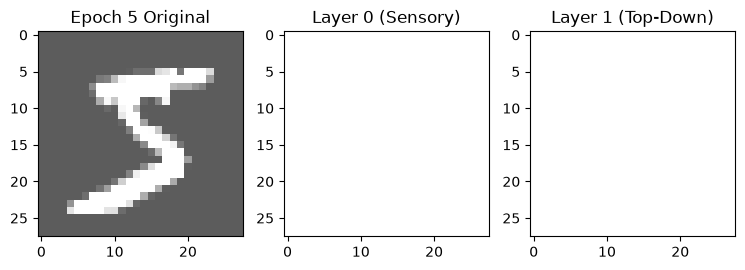

KeyboardInterrupt: 

In [ ]:
def main():
    num_data = 100
    images = [input_data[i][0] for i in range(num_data)]
    num_train_epochs = 100
    alpha = 0.001
    lambda_u = 0.001
    lr_r = 0.005
    lr_U = 0.002
    sigma_2 = 1.0
    num_layers = 2
    num_patches = 16

    f = lambda x: x
    f_prime = lambda x: torch.ones_like(x)

    num_epochs_inner = 50
    num_epochs_outer = 1

    print("=" * 60)
    print(f"Starting Training: {num_train_epochs} Epochs | {num_data} Images | {num_layers} Layers")
    print(f"Hyperparameters: lr_r={lr_r}, lr_U={lr_U}, alpha={alpha}, lambda_u={lambda_u}")
    print("=" * 60)

    _, k, _, size = make_variables(images[0], num_layers=num_layers, num_patches=num_patches)
    r_bank = [[torch.randn(k[i], 1) * 0.1 for i in range(num_layers)] for _ in images]
   
    U = init_U(images, size, k, num_layers, num_patches)
    
    for epoch in range(num_train_epochs):
        r0_list = []
        for i, image in enumerate(images):
            image_centered = image - image.mean()
            I, k, _, size = make_variables(image_centered, num_layers=num_layers, num_patches=num_patches)
            U, r_bank[i] = train_loop(I, U, r_bank[i], f, f_prime, alpha, lambda_u, lr_r, lr_U, sigma_2, num_epochs_outer, num_epochs_inner, num_layers)
            r0_list.append(r_bank[i][0].detach())
        
        
        if epoch % 5 == 0 or epoch == num_train_epochs - 1:
            test_img = images[0] - images[0].mean()
            I, k, _, size = make_variables(test_img, num_layers=num_layers, num_patches=num_patches)
            _, r_bank[0] = test(I, U, r_bank[0], f, f_prime, num_epochs_inner, num_layers, sigma_2, alpha, lr_r)
            
            mse_L0, mse_L1, I_hat_L0, I_hat_L1 = validate_heirarchical(I, U, r_bank[0], num_layers, f)

            r0_mag = r_bank[0][0].abs().mean().item()
            r1_mag = r_bank[0][1].abs().mean().item()
            print(f"[Epoch {epoch:03d}/{num_train_epochs:03d}]  Layer 0 MSE: {mse_L0:.6f} (|r0|: {r0_mag:.4f})  |  Layer 1 MSE: {mse_L1:.6f} (|r1|: {r1_mag:.4f})") 

            fig, axes = plt.subplots(1, 3, figsize=(9, 3))
            axes[0].imshow(I.reshape(28, 28).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
            axes[0].set_title(f"Epoch {epoch} Original")
            
            axes[1].imshow(I_hat_L0.reshape(28, 28).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
            axes[1].set_title("Layer 0 (Sensory)")
            
            axes[2].imshow(I_hat_L1.reshape(28, 28).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
            axes[2].set_title("Layer 1 (Top-Down)")
            plt.show()
    
    val_img = input_data[num_data][0] - input_data[num_data][0].mean()
    I, k, r, size = make_variables(val_img, num_layers=num_layers, num_patches=num_patches)
    _, r = test(I, U, r, f, f_prime, num_epochs_inner, num_layers, sigma_2, alpha, lr_r)
    mse_L0, mse_L1, I_hat_L0, I_hat_L1 = validate_heirarchical(I, U, r, num_layers, f)

    r0_mag_val = r[0].abs().mean().item()
    r1_mag_val = r[1].abs().mean().item()
    print(f"Validation Metrics  ->  Layer 0 MSE: {mse_L0:.6f} (|r0|: {r0_mag_val:.4f})  |  Layer 1 MSE: {mse_L1:.6f} (|r1|: {r1_mag_val:.4f})")
    
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(I.reshape(28, 28).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
    axes[0].set_title("Validation Original")
    axes[1].imshow(I_hat_L0.reshape(28, 28).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
    axes[1].set_title("Layer 0 (Sensory)")
    axes[2].imshow(I_hat_L1.reshape(28, 28).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
    axes[2].set_title("Layer 1 (Top-Down)")
    plt.show()

if __name__ == "__main__":
    main()
